Пробвай да промениш дължината на клиповете, така че да визмаш предвид само първите няколко минути или първите 50%.
Пробвай да промениш сийда. Може тоя да е скапан.
#Пробвай да направиш системата да работи за един определен човек. Не за всичо и висчки. 

In [1]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import numpy as np
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import copy
import json
from pathlib import Path
import torch.profiler
from enum import Enum
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
)
import matplotlib.pyplot as plt
import os
import random
from sklearn.model_selection import StratifiedGroupKFold

torch.set_float32_matmul_precision('high')
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)

In [2]:
def seed_all(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [3]:
class ModelType(Enum):
    CNN = 1
    LSTM = 2
    CNN_LSTM = 3
    LSTM_CNN = 4
    CNN_LSTM_Fusion = 5
    CNN_Transformer = 6
    MLP = 7

class EvalMetric(Enum):
    accuracy = 1
    F1 = 2
    custom = 3

class ExperimentType(Enum):
    fixed_model_params = 1
    best_model = 2

In [4]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

torch.backends.cudnn.benchmark = True

print(device)

cuda


In [5]:
root = "../../"
data_path = f'{root}data/'
training_data_path = data_path + "Final Training Data/"

In [6]:
class CNN(nn.Module):
    def __init__(self, input_channels, num_classes, activation_fn, dropout=0.2):
        super().__init__()

        C = 100  

        self.features = nn.Sequential(
            nn.Conv1d(input_channels, C, 5, padding=2),
            nn.BatchNorm1d(C),
            activation_fn(),

            nn.Conv1d(C, C, 5, padding=2),
            nn.BatchNorm1d(C),
            activation_fn(),

            nn.Conv1d(C, C, 3, padding=1),
            nn.BatchNorm1d(C),
            activation_fn(),
        )

        self.pool = nn.AdaptiveAvgPool1d(1)

        self.classifier = nn.Sequential(
            nn.Linear(C, C),
            activation_fn(),
            nn.Dropout(dropout),
            nn.Linear(C, num_classes)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.features(x)
        x = self.pool(x).squeeze(-1)
        return self.classifier(x)



        
class LSTM(nn.Module):
    def __init__(self, input_size, num_classes, dropout=0.2):
        super().__init__()

        H = 130  

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=H,
            num_layers=1,   
            batch_first=True,
            dropout=0
        )

        self.head = nn.Sequential(
            nn.Linear(H, H),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(H, num_classes)
        )

    def forward(self, x):
        x, _ = self.lstm(x)
        x = x.mean(dim=1)
        return self.head(x)

class AttentionPooling(nn.Module):
    """
    Learns which time steps are important instead of averaging blindly.
    """
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, x):

        weights = self.attn(x)             
        weights = torch.softmax(weights, dim=1)

        pooled = torch.sum(x * weights, dim=1)
        return pooled





class CNN_LSTM(nn.Module):
    def __init__(self, input_channels, num_classes, activation_fn, dropout=0.3):
        super().__init__()

        C = 96   # stronger feature space than 80
        H = 128  # stronger temporal embedding

        # ---------------- CNN FEATURE EXTRACTOR ----------------
        self.cnn = nn.Sequential(
            nn.Conv1d(input_channels, C, kernel_size=5, padding=2),
            nn.BatchNorm1d(C),
            activation_fn(),
            nn.Dropout(0.1),

            nn.Conv1d(C, C, kernel_size=5, padding=2),
            nn.BatchNorm1d(C),
            activation_fn(),
            nn.Dropout(0.1),

            nn.Conv1d(C, C, kernel_size=3, padding=1),
            nn.BatchNorm1d(C),
            activation_fn(),

            nn.MaxPool1d(2)
        )

        # ---------------- LSTM ----------------
        self.lstm = nn.LSTM(
            input_size=C,
            hidden_size=H,
            num_layers=2,
            batch_first=True,
            dropout=0.2
        )

        self.norm = nn.LayerNorm(H)

        # ---------------- POOLING ----------------
        self.pool = AttentionPooling(H)

        # ---------------- CLASSIFIER HEAD ----------------
        self.head = nn.Sequential(
            nn.Linear(H, H),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(H, H // 2),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(H // 2, num_classes)
        )

    def forward(self, x):
        # x: (B, T, F)

        x = x.permute(0, 2, 1)  

        x = self.cnn(x)         

        x = x.permute(0, 2, 1)  

        x, _ = self.lstm(x)      

        x = self.norm(x)

        x = self.pool(x)         

        return self.head(x)




class CNN_Transformer(nn.Module):
    def __init__(self, input_channels, output_channels, num_layers, num_classes, feature_dim, activation_fn, dropout=0.3):
        super().__init__()

        C = output_channels

        self.cnn = nn.Sequential(
            nn.Conv1d(input_channels, C, 5, padding=2),
            nn.BatchNorm1d(C),
            activation_fn(),

            nn.Conv1d(C, C, 5, padding=2),
            nn.BatchNorm1d(C),
            activation_fn(),

            nn.MaxPool1d(2)
        )

        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=C,
                nhead=4,
                batch_first=True
            ),
            num_layers=num_layers
        )

        self.fusion = nn.Sequential(
            nn.Linear(C + feature_dim, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x, x_engineered):
        x = x.permute(0, 2, 1)
        x = self.cnn(x)
        x = x.permute(0, 2, 1)

        x = self.transformer(x)
        x = x.mean(dim=1)

        x = torch.cat([x, x_engineered], dim=1)
        return self.fusion(x)



        
class LSTM_CNN(nn.Module):
    def __init__(self, input_size, num_classes, activation_fn, dropout=0.2):
        super().__init__()

        H = 85  

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=H,
            num_layers=1,
            batch_first=True
        )

        self.cnn = nn.Sequential(
            nn.Conv1d(H, H, 5, padding=2),
            nn.BatchNorm1d(H),
            activation_fn(),

            nn.MaxPool1d(2),

            nn.Conv1d(H, H, 3, padding=1),
            activation_fn(),
        )

        self.pool = nn.AdaptiveAvgPool1d(1)

        self.head = nn.Sequential(
            nn.Linear(H, H),
            activation_fn(),
            nn.Dropout(dropout),
            nn.Linear(H, num_classes)
        )

    def forward(self, x):
        x, _ = self.lstm(x)
        x = x.permute(0, 2, 1)
        x = self.cnn(x)
        x = self.pool(x).squeeze(-1)
        return self.head(x)





class CNN_LSTM_Fusion(nn.Module):
    def __init__(self, input_channels, output_channels, hidden_size, num_layers, num_classes, activation_fn, dropout=0.2):
        super().__init__()

        C = output_channels
        H = hidden_size  

        # CNN branch
        self.cnn = nn.Sequential(
            nn.Conv1d(input_channels, C, 5, padding=2),
            nn.BatchNorm1d(C),
            activation_fn(),

            nn.MaxPool1d(2),
        )

        # LSTM branch
        self.lstm = nn.LSTM(
            input_size=input_channels,
            hidden_size=H,
            num_layers=num_layers,
            batch_first=True
        )

        # fusion head
        self.classifier = nn.Sequential(
            nn.Linear(C + H, 96),
            activation_fn(),
            nn.Dropout(dropout),
            nn.Linear(96, num_classes)
        )

    def forward(self, x):
        # CNN
        x_cnn = x.permute(0, 2, 1)
        x_cnn = self.cnn(x_cnn)
        x_cnn = x_cnn.mean(dim=-1)

        # LSTM
        x_lstm, _ = self.lstm(x)
        x_lstm = x_lstm.mean(dim=1)

        x = torch.cat([x_cnn, x_lstm], dim=1)
        return self.classifier(x)



        
class MLP(nn.Module):
    def __init__(self, input_features, num_classes, activation_fn, dropout=0.3):
        super().__init__()

        H = 128

        self.net = nn.Sequential(
            nn.Linear(input_features, H),
            nn.LayerNorm(H),
            activation_fn(),
            nn.Dropout(dropout),

            nn.Linear(H, H),
            nn.LayerNorm(H),
            activation_fn(),
            nn.Dropout(dropout),

            nn.Linear(H, num_classes)
        )

    def forward(self, x):
        return self.net(x)

In [7]:
def load_npz(path, subject_root_path, subject):
    path = Path(path)
    data = np.load(f"{path}.npz", allow_pickle=True)
    relative_windows_times = np.load(subject_root_path / f"{subject}_window_times.npz", allow_pickle=True)
    return data["X"], data["y"], relative_windows_times["window_times"]

def load_subject(cache_dir, subject, use_raw, use_engineered):
    X_raw = None
    X_engineered = None
    y = None

    cache_dir = Path(cache_dir)
    subject_root_path = cache_dir / subject
    if use_raw:
        X_raw, y, relative_windows_times = load_npz(subject_root_path / f"{subject}_raw", subject_root_path, subject)

    if use_engineered:
        X_engineered, y_engineered, relative_windows_times = load_npz(subject_root_path / f"{subject}_extracted", subject_root_path, subject)

        if y is None:
            y = y_engineered
        elif not np.array_equal(y, y_engineered):
            raise ValueError("Labels do not match")

    return X_raw, X_engineered, y, relative_windows_times

def get_subjects(cache_dir, use_raw, use_engineered):
    cache_dir = Path(cache_dir)
    subjects = set()

    if use_raw:
        subjects.update(
            p.stem.removesuffix("_raw")
            for p in Path(cache_dir).rglob("*_raw.npz")
        )

    if use_engineered:
        subjects.update(
            p.stem.removesuffix("_extracted")
            for p in Path(cache_dir).rglob("*_extracted.npz")
        )

    return sorted(subjects)

In [8]:
def compute_accuracy(y_true, y_pred):
    return accuracy_score(y_true, y_pred)

def compute_f1_score(y_true, y_pred):
    return f1_score(
            y_true, y_pred,
            average="macro",
            zero_division=0
    )

def compute_metrics(y_true, y_pred):
    return {
        "accuracy": compute_accuracy(y_true, y_pred),
        "precision_macro": precision_score(
            y_true, y_pred,
            average="macro",
            zero_division=0
        ),
        "recall_macro": recall_score(
            y_true, y_pred,
            average="macro",
            zero_division=0
        ),
        "f1_macro": compute_f1_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(
            y_true, y_pred
        ),
        "confusion_matrix": confusion_matrix(y_true, y_pred),
        "classification_report": classification_report(
            y_true,
            y_pred,
            digits=4,
            zero_division=0,
            output_dict=True
        )
    }

In [9]:
def get_loader(settings, X_train_raw, X_train_extracted, y_train):
    sampler = None
    shuffle = True
    batch_size = settings["batch size"]
    if settings["weight"] == "weighted":
            
        class_counts = np.bincount(y_train)
        weights = class_counts.sum() / class_counts
        
        weights = weights / weights.mean()
        #weights = 1.0 / class_counts
        
        weights = torch.tensor(weights, dtype=torch.float32).to(device)

        loss_fn = torch.nn.CrossEntropyLoss(weight=weights)
    else:
        loss_fn = torch.nn.CrossEntropyLoss(label_smoothing = settings["label smoothing"])

    if X_train_raw is None:
        X_train_raw = torch.empty((len(y_train), 0, 0), dtype=torch.float32)

    if X_train_extracted is None:
        X_train_extracted = torch.empty((len(y_train), 0), dtype=torch.float32)

    return DataLoader(
                    TensorDataset(X_train_raw, X_train_extracted, y_train),
                    batch_size=batch_size,
                    shuffle=shuffle,
                    sampler=sampler,
                    #num_workers=2,
                    pin_memory=True,
                    #prefetch_factor=2
                ), loss_fn

In [10]:
# Gradient Accumulation
def train_epoch(model, loader, optimizer, loss_fn, accumulation_steps=64):
    model.train()
    optimizer.zero_grad()
    for i, (X_batch_raw, X_batch_extracted, y_batch) in enumerate(loader):
        X_batch_raw = X_batch_raw.to(device, non_blocking=True)
        X_batch_extracted = X_batch_extracted.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)

        torch.compiler.cudagraph_mark_step_begin()
        
        with torch.amp.autocast(device_type="cuda"):
            logits = model_forward(model, X_batch_raw, X_batch_extracted)
            loss = loss_fn(logits, y_batch)
            loss = loss / accumulation_steps
        
        loss.backward()
        
        if (i + 1) % accumulation_steps == 0:
            optimizer.step()
            optimizer.zero_grad()

def validate_epoch(model, X_val_raw, X_val_extracted, y_val, metadata):

    model.eval()

    with torch.no_grad():

        X_val_raw = X_val_raw.to(device)
        X_val_extracted = X_val_extracted.to(device)
        y_val = y_val.to(device)

        logits = model_forward(
            model,
            X_val_raw,
            X_val_extracted
        )

        probs = torch.softmax(logits, dim=1)

        preds = torch.argmax(probs, dim=1)
        preds = preds.cpu().numpy()

        if metadata["eval_metric"] == EvalMetric.accuracy:
            val_metric = compute_accuracy(
                y_val.cpu(),
                preds
            )

        elif metadata["eval_metric"] == EvalMetric.F1:
            val_metric = compute_f1_score(
                y_val.cpu(),
                preds
            )
        else:
            confidences, preds = torch.max(probs, dim=1)

            mask = confidences >= 0.8

            if mask.sum() == 0:
                val_metric = 0
            else:
                coverage = mask.float().mean().item()
                precision = (
                    preds[mask] == y_val[mask]
                ).float().mean().item()

                val_metric = precision * coverage

    return val_metric

def model_forward(model, x_raw, x_extracted):

    has_raw = x_raw.numel() > 0
    has_extracted = x_extracted.numel() > 0

    if has_raw and has_extracted:
        return model(x_raw, x_extracted)

    if has_raw:
        return model(x_raw)

    if has_extracted:
        return model(x_extracted)

    raise ValueError("No input features provided")

In [11]:
def get_model(model_settings, X_train_main_raw, X_train_main_extracted, y_train_main):
    match model_settings["activation_fn"]:
        case "relu":
            activation_fn = nn.ReLU
        case "gelu":
            activation_fn = nn.GELU

    dropout = model_settings["dropout"]
    hidden_size = model_settings["hidden_size"]
    num_layers = model_settings["num_layers"]
    output_channles = model_settings["output_channels"]

    input_channels_raw = X_train_main_raw.shape[-1]
    input_channels_extracted = X_train_main_extracted.shape[1]
    num_classes = len(torch.unique(y_train_main))
    
    match model_settings["model"]:
        case ModelType.CNN:
            model = CNN(
                input_channels_raw,
                output_channles,
                num_classes,
                activation_fn
            ).to(device)
        case ModelType.LSTM:
            model = LSTM(
                input_channels_raw,
                num_classes,
            ).to(device)
        case ModelType.CNN_LSTM:
            model = CNN_LSTM(
                input_channels_raw, 
                num_classes,
                activation_fn,
                dropout
            ).to(device)
        case ModelType.LSTM_CNN:
            model = LSTM_CNN(
                input_channels_raw,
                num_classes,
                activation_fn,
                dropout
            ).to(device)
        case ModelType.CNN_Transformer:
            model = CNN_Transformer(
                input_channels_raw,
                output_channles,
                num_layers,
                num_classes,
                input_channels_extracted,
                activation_fn,
                dropout
            ).to(device)
        case ModelType.CNN_LSTM_Fusion:
            model = CNN_LSTM_Fusion(
                input_channels_raw,
                output_channles,
                hidden_size,
                num_layers,
                num_classes,
                activation_fn,
                dropout
            ).to(device)
        case ModelType.MLP:
            model = MLP(
                input_channels_extracted,
                num_classes,
                activation_fn,
                dropout
            ).to(device)

    return model

In [12]:
def model_forward(model, x_raw, x_extracted):

    has_raw = x_raw.numel() > 0
    has_extracted = x_extracted.numel() > 0

    if has_raw and has_extracted:
        return model(x_raw, x_extracted)

    if has_raw:
        return model(x_raw)

    if has_extracted:
        return model(x_extracted)

    raise ValueError("No input features provided")

In [13]:
def create_subject_split(relative_times, n_blocks = 20):

    blocks = np.floor(relative_times * n_blocks).astype(int)

    return blocks

In [14]:
def train(
    X_raw, X_extracted, y, 
    relative_windows_times,
    subject_idx, test_subject,
    settings, metadata,
):
    # ------------------------------------------------------------------
    # Convert to CPU tensors
    # ------------------------------------------------------------------
    if X_raw is not None:
        X_raw = torch.tensor(X_raw, dtype=torch.float32)

    if X_extracted is not None:
        X_extracted = torch.tensor(X_extracted, dtype=torch.float32)

    y = torch.tensor(y, dtype=torch.long)

    # ------------------------------------------------------------------
    # Split train / validation
    # ------------------------------------------------------------------
    split_source = X_raw if X_raw is not None else X_extracted
    
    split_np = split_source.numpy()
    y_np = y.numpy()
    
    groups = create_subject_split(
        relative_windows_times
    )
    
    splitter = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=seed
    )
    
    splits = list(
        splitter.split(
            split_np,
            y_np,
            groups
        )
    )
    
    test_idx = splits[0][1]
    val_idx = splits[1][1]
    
    train_idx = np.setdiff1d(
        np.arange(len(y)),
        np.concatenate([
            test_idx,
            val_idx
        ])
    )

    print(
        "Train blocks:",
        np.unique(groups[train_idx])
    )
    
    print(
        "Val blocks:",
        np.unique(groups[val_idx])
    )
    
    print(
        "Test blocks:",
        np.unique(groups[test_idx])
    )

    assert len(set(groups[train_idx]) & set(groups[val_idx])) == 0
    assert len(set(groups[train_idx]) & set(groups[test_idx])) == 0
    assert len(set(groups[val_idx]) & set(groups[test_idx])) == 0
    # ------------------------------------------------------------------
    # Slice data
    # ------------------------------------------------------------------
    X_train_raw = None
    X_val_raw = None
    X_test_raw = None

    X_train_extracted = None
    X_val_extracted = None
    X_test_extracted = None
    
    if X_raw is not None:
        X_train_raw = X_raw[train_idx]
        X_val_raw = X_raw[val_idx]
        X_test_raw = X_raw[test_idx]

    if X_extracted is not None:
        X_train_extracted = X_extracted[train_idx]
        X_val_extracted = X_extracted[val_idx]
        X_test_extracted = X_extracted[test_idx]
        
    y_train = y[train_idx]
    y_val = y[val_idx]
    y_test = y[test_idx]

    mean = X_train_raw.mean(dim=(0,1), keepdim=True)
    std = X_train_raw.std(dim=(0,1), keepdim=True)

    X_train_raw = (X_train_raw - mean) / (std + 1e-8)
    X_val_raw = (X_val_raw - mean) / (std + 1e-8)
    X_test_raw = (X_test_raw - mean) / (std + 1e-8)

    
    if metadata["eval_metric"] == EvalMetric.custom:
        y_val = y_val.float()


    if X_train_raw is None:
        X_train_raw = torch.empty(
            (len(y_train), 0, 0),
            dtype=torch.float32
        )
    
    if X_val_raw is None:
        X_val_raw = torch.empty(
            (len(y_val), 0, 0),
            dtype=torch.float32
        )

    if X_test_raw is None:
        X_test_raw = torch.empty(
            (len(y_test), 0, 0),
            dtype=torch.float32
        )
    
    if X_train_extracted is None:
        X_train_extracted = torch.empty(
            (len(y_train), 0),
            dtype=torch.float32
        )
    
    if X_val_extracted is None:
        X_val_extracted = torch.empty(
            (len(y_val), 0),
            dtype=torch.float32
        )

    if X_test_extracted is None:
        X_test_extracted = torch.empty(
            (len(y_test), 0),
            dtype=torch.float32
        )

    
    print("Train", np.bincount(y_train))
    print("Val", np.bincount(y_val))
    print("Test", np.bincount(y_test))
    # ------------------------------------------------------------------
    # Model
    # ------------------------------------------------------------------
    model = get_model(
        settings["model settings"],
        X_train_raw,
        X_train_extracted,
        y_train,
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=settings["training settings"]["learning rate"],
        weight_decay=settings["training settings"]["weight decay"],
    )

    loader, loss_fn = get_loader(
        settings["training settings"],
        X_train_raw,
        X_train_extracted,
        y_train,
    )

    # ------------------------------------------------------------------
    # Training
    # ------------------------------------------------------------------
    best_val = -1
    best_state = copy.deepcopy(model.state_dict())
    patience_counter = 0

    for epoch in range(settings["training settings"]["epoch"]):

        train_epoch(
            model,
            loader,
            optimizer,
            loss_fn,
            settings["training settings"]["accumulation_steps"],
        )

        val_score = validate_epoch(
            model,
            X_val_raw,
            X_val_extracted,
            y_val,
            metadata
        )

        if val_score > best_val:
            best_val = val_score
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= settings["training settings"]["patience"]:
            break

    print(epoch - patience_counter)

    model.load_state_dict(best_state)

    # ------------------------------------------------------------------
    # Test
    # ------------------------------------------------------------------
    model.eval()

    with torch.no_grad():
        
        logits = model_forward(
            model,
            X_test_raw.to(device),
            X_test_extracted.to(device),
        )

        prob = torch.softmax(logits, dim=1).cpu()

        confidences, preds = torch.max(prob, dim=1)

    return (
        preds.numpy(),
        confidences,
        prob,
        model,
        y_test
    )

In [15]:
def normalize_train_test_raw(X_train, X_test, eps=1e-8):
    mean = X_train.mean(axis=(0, 1), keepdims=True)
    std = X_train.std(axis=(0, 1), keepdims=True)

    X_train = (X_train - mean) / (std + eps)
    X_test = (X_test - mean) / (std + eps)

    return X_train, X_test

def normalize_train_test_engineered(X_train, X_test, eps=1e-8):
    mean = X_train.mean(axis=0, keepdims=True)
    std = X_train.std(axis=0, keepdims=True)

    X_train = (X_train - mean) / (std + eps)
    X_test = (X_test - mean) / (std + eps)

    return X_train, X_test

In [16]:
def plot_confusion_matrix(cm, class_names, title="Confusion Matrix"):
    plt.figure(figsize=(7, 6))
    plt.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.title(title)
    plt.colorbar()

    # set axis labels using class names
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45, ha="right")
    plt.yticks(tick_marks, class_names, rotation=45)
    
    plt.xlabel("Predicted label")
    plt.ylabel("True label")

    # annotate values inside cells
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j, i,
                format(cm[i, j], "d"),
                ha="center",
                va="center",
                color="white" if cm[i, j] > thresh else "black"
            )

    plt.tight_layout()
    plt.show()

def evaluate_per_fold(per_fold_preds, per_fold_y_test):
    """
    Computes metrics per fold and plots them.
    
    Returns:
        fold_metrics: list of dicts (one per fold)
    """

    fold_metrics = []

    for i, item in enumerate(per_fold_preds):
        y_pred = np.array(item["pred"])
        y_true = np.array(per_fold_y_test[i])

        metrics = compute_metrics(y_true, y_pred)
        fold_metrics.append(metrics)

    # -------------------------
    # PLOTTING (per fold)
    # -------------------------
    folds = np.arange(len(fold_metrics))

    accs = [m["accuracy"] for m in fold_metrics]
    f1s = [m["f1_macro"] for m in fold_metrics]
    bals = [m["balanced_accuracy"] for m in fold_metrics]

    plt.figure()
    plt.plot(folds, accs, label="Accuracy")
    plt.plot(folds, f1s, label="Macro F1")
    plt.plot(folds, bals, label="Balanced Acc")

    plt.xlabel("Fold (Subject)")
    plt.ylabel("Score")
    plt.title("Per-Fold Performance")
    plt.legend()
    plt.grid()
    plt.show()

    return fold_metrics

def evaluate_final(fold_metrics, per_fold_preds, per_fold_y_test):
    """
    Aggregates metrics across all folds and plots final results.
    """

    # -------------------------
    # Aggregate scalar metrics
    # -------------------------
    accs = np.array([m["accuracy"] for m in fold_metrics])
    precs = np.array([m["precision_macro"] for m in fold_metrics])
    recs = np.array([m["recall_macro"] for m in fold_metrics])
    f1s = np.array([m["f1_macro"] for m in fold_metrics])
    bals = np.array([m["balanced_accuracy"] for m in fold_metrics])

    print("\n===== FINAL RESULTS =====")
    print(f"Model:             {settings['model settings']['model']}")
    print(f"Seed:              {seed}")
    print(f"Accuracy:          {accs.mean():.4f} ± {accs.std():.4f}")
    print(f"Precision (macro): {precs.mean():.4f} ± {precs.std():.4f}")
    print(f"Recall (macro):    {recs.mean():.4f} ± {recs.std():.4f}")
    print(f"F1 macro:          {f1s.mean():.4f} ± {f1s.std():.4f}")
    print(f"Balanced Acc:      {bals.mean():.4f} ± {bals.std():.4f}")

    # -------------------------
    # Global confusion matrix
    # -------------------------
    all_y_true = []
    all_y_pred = []

    for i, item in enumerate(per_fold_preds):
        all_y_pred.extend(item["pred"])
        all_y_true.extend(per_fold_y_test[i])

    class_names = ["Looking at guide book", "Assembling", "Searching for pieces"]
    cm = confusion_matrix(all_y_true, all_y_pred)
    print(f"Confusion matrix: {cm}")
    plot_confusion_matrix(cm, class_names)

    # -------------------------
    # Metric summary plot
    # -------------------------
    labels = ["Acc", "Prec", "Rec", "F1", "BalAcc"]
    means = [accs.mean(), precs.mean(), recs.mean(), f1s.mean(), bals.mean()]

    plt.figure()
    plt.bar(labels, means)
    plt.ylim(0, 1)
    plt.title("Average Metrics Across Folds")
    plt.grid(axis="y")
    plt.show()

    return {
        "accuracy": (accs.mean(), accs.std()),
        "precision_macro": (precs.mean(), precs.std()),
        "recall_macro": (recs.mean(), recs.std()),
        "f1_macro": (f1s.mean(), f1s.std()),
        "balanced_accuracy": (bals.mean(), bals.std()),
        "confusion_matrix": cm
    }

In [17]:
def save_model_settings(metadata, settings):
    path = root + "experiments"
    
    settings = getSettingsAsDict(metadata, settings) 
    experiment_type = settings["experiment_type"]
    eval_metric = settings["eval_metric"]
    model_type = settings["model_type"]  

    results_path = f"{path}/{experiment_type}/{eval_metric}/results/{model_type}/"
    relative_model_path = f"../../models/{model_type}/"
    
    os.makedirs(results_path, exist_ok=True)

    config = {
        "settings": copy.deepcopy(result["settings"]),
        "windowing_setting_hash": result["windowing_setting_hash"],
        "relative_model_path": relative_model_path
    }
    config["settings"]["model settings"]["model"] = model_type

    with open(f"{results_path}config.json", "w") as f:
        json.dump(config, f, indent=2)

def getSettingsAsDict(metadata, settings):
    match metadata["experiment_type"]:
        case ExperimentType.fixed_model_params:
            experiment_type = "fixed_model_params"
        case ExperimentType.best_model:
            experiment_type = "best_model"
    
    match settings["model settings"]["model"]:
        case ModelType.CNN:
            model_type = "CNN"
        case ModelType.LSTM:
            model_type = "LSTM"
        case ModelType.CNN_LSTM:
            model_type = "CNN_LSTM"
        case ModelType.LSTM_CNN:
            model_type = "LSTM_CNN"
        case ModelType.CNN_LSTM_Fusion:
            model_type = "CNN_LSTM_Fusion"
        case ModelType.CNN_Transformer:
            model_type = "CNN_Transformer"
            
    match metadata["eval_metric"]:
        case EvalMetric.accuracy:
            eval_metric = "accuracy"
        case EvalMetric.F1:
            eval_metric = "macro_f1"
    return {
        "experiment_type": experiment_type,
        "model_type": model_type,
        "eval_metric": eval_metric
    }

def save_model(metadata, result, subject_id, model):
    path = root + "experiments"
    
    settings = getSettingsAsDict(metadata, result["settings"]) 
    experiment_type = settings["experiment_type"]
    eval_metric = settings["eval_metric"]
    model_type = settings["model_type"]  
    
    models_path = f"{path}/{experiment_type}/{eval_metric}/models/{model_type}/"
    results_path = f"{path}/{experiment_type}/{eval_metric}/results/{model_type}/{subject_id}/"
    
    os.makedirs(models_path, exist_ok=True)
    os.makedirs(results_path, exist_ok=True)
    
    torch.save(model.state_dict(), f"{models_path}/{subject_id}.pt")

    np.save(f"{results_path}y_true.npy", result["y_true"])
    np.save(f"{results_path}y_pred.npy", result["y_pred"])
    np.save(f"{results_path}prob.npy", result["probabilities"])
    np.save(f"{results_path}conf.npy", result["confidences"])
    

In [18]:
settings = {
    "training settings": {
        "learning rate": 0.0000767676342,
        "weight decay": 0.0031726730770640136,

        "patience": 15,
        "epoch": 150,
        
        "weight": None,
        "label smoothing": 0.2920273452973996,
        "batch size": 512,
        "accumulation_steps": 10,
    },
    "model settings": {
        "model": ModelType.CNN_Transformer,
        "activation_fn": "gelu",
        "dropout": 0.9489233057908638,      
        "output_channels": 512,
        "hidden_size": 32,
        "num_layers": 1,
    }
}

model_type = settings["model settings"]["model"]

use_raw = model_type in [
    ModelType.CNN,
    ModelType.LSTM,
    ModelType.CNN_LSTM,
    ModelType.LSTM_CNN,
    ModelType.CNN_Transformer,
    ModelType.CNN_LSTM_Fusion,
]

use_engineered = model_type in [
    ModelType.MLP,
    ModelType.CNN_Transformer,
]

files_suffix = "_raw" if use_raw else "_extracted"

In [19]:
cache_hash = "9a8e918cf3c537bbff7cfd9ed785b515"
cache_dir = f"{data_path}Final Training Data/Windowed Data/{cache_hash}"

subjects = get_subjects(cache_dir, use_raw, use_engineered)

In [20]:
save_experement = False
metadata = {
        "eval_metric": EvalMetric.accuracy,
        "experiment_type": ExperimentType.best_model,
}

per_fold_preds = []
per_fold_y = []

best_seed = 0
best_val_metric = 0
num_seed_runs = 1

if Path("best_seed.json").exists():
    with open("best_seed.json") as f:
        best_file = json.load(f)
        best_seed = best_file["seed"]
        best_val_metric = best_file["val metric"]


for i in range(num_seed_runs):
    seed = 42 if num_seed_runs == 1 else random.randint(1, 10000000)
    seed_all(seed)
    
    for subject_idx, test_subject in enumerate(subjects):
        
        test_subject = test_subject.removesuffix(files_suffix)
        print(f"\nSubject {subject_idx}: {test_subject}")
        print("Loading data...")
    
        X_train_raw_list = []
        X_train_engineered_list = []
        y_train_list = []
        
        X_raw, X_engineered, y, relative_windows_times = load_subject(cache_dir, test_subject, use_raw, use_engineered)

    
        #plot_pca_tsne(X_train, y_train)

        
        print("Training...")
        pred, confidences, prob, model, y_test = train(
            X_raw, X_engineered, y, 
            relative_windows_times,
            subject_idx, test_subject,
            settings, metadata
        )

        per_fold_y.append(y_test)
        
        if save_experement:
            result = {
                "y_true": y.tolist(),
                "y_pred": pred.tolist(),
        
                "probabilities": prob.tolist(),
                "confidences": confidences.tolist(),
        
                "settings": settings,
                "windowing_setting_hash": cache_hash
            }
            
            save_model(metadata, result, test_subject, model)
        
        per_fold_preds.append({
            "subject": test_subject,
            "pred": pred
        })

    if save_experement:
        save_model_settings(metadata, settings)
        
    fold_metrics = []

    for i, item in enumerate(per_fold_preds):
        y_pred = np.array(item["pred"])
        y_true = np.array(per_fold_y[i])

        metrics = compute_accuracy(y_true, y_pred)
        fold_metrics.append(metrics)


    if num_seed_runs != 1:
        metrics_mean = np.array(fold_metrics).mean()
        print(f"Current best seed: {best_seed}")
        print(f"Current best val metric: {best_val_metric}")
        print("")
        print(f"Current seed: {seed}")
        print(f"Current metric: {metrics_mean}")
    
        if best_val_metric < metrics_mean:
            best_val_metric = metrics_mean
            best_seed = seed
            with open(f"best_seed.json", "w") as f:
                json.dump({"seed": best_seed, "val metric": best_val_metric}, f, indent=2)
            
        print("")
        print("")
        print("")


Subject 0: 0fc57dc8-de68-4b41-bf69-59a5a5f2d27e
Loading data...
Training...
Train blocks: [ 2  3  4  7  8 10 11 12 13 15 16 17 19]
Val blocks: [0 5 6]
Test blocks: [ 1  9 14 18]
Train [169 149 150]
Val [24 55 39]
Test [60 45 32]
0

Subject 1: 10b8d8be-39de-43e7-9260-ba4cc724d4ae
Loading data...
Training...
Train blocks: [ 0  3  4  5  8  9 10 11 13 14 16 18]
Val blocks: [ 1  6 12 17]
Test blocks: [ 2  7 15 19]
Train [192 287 184]
Val [ 53  58 100]
Test [76 68 72]
0

Subject 2: 1279952d-14d4-4e77-9010-a000dd546bcd
Loading data...
Training...
Train blocks: [ 1  4  6  8  9 10 11 13 14 15 17 18]
Val blocks: [ 0 12 16 19]
Test blocks: [2 3 5 7]
Train [173 291 285]
Val [ 74 121  50]
Test [ 50 119  83]
0

Subject 3: 1477b633-8ef3-4123-9ecc-f2ee90d13d8c
Loading data...
Training...
Train blocks: [ 1  4  5  6  7  8 10 11 15 16 17 18]
Val blocks: [ 3  9 14 19]
Test blocks: [ 0  2 12 13]
Train [448 293 306]
Val [182  84 105]
Test [142 134  95]
0

Subject 4: 383b0fe8-654a-4f4f-84cd-375470069789
Loa

/tmp/ipykernel_10255/939578451.py:77: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y_true = np.array(per_fold_y[i])
/tmp/ipykernel_10255/939578451.py:77: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y_true = np.array(per_fold_y[i])
/tmp/ipykernel_10255/939578451.py:77: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guid

In [21]:
def export_class_stats(X_embedded, y):
    classes = np.unique(y)

    output = []

    for c in classes:
        mask = y == c
        pts = X_embedded[mask]

        output.append(f"{c}:")
        output.append(f"  mean = ({pts[:,0].mean():.4f}, {pts[:,1].mean():.4f})")
        output.append(f"  std  = ({pts[:,0].std():.4f}, {pts[:,1].std():.4f})")
        output.append("")

    return "\n".join(output)

def export_embedding_json(X_embedded, y, path=None, max_points=None):
    data = []

    n = len(X_embedded)
    idx = np.arange(n)

    # Optional subsample (important if dataset is large)
    if max_points is not None and n > max_points:
        idx = np.random.choice(idx, max_points, replace=False)

    for i in idx:
        data.append({
            "label": str(y[i]),
            "x": float(X_embedded[i, 0]),
            "y": float(X_embedded[i, 1])
        })

    json_str = json.dumps(data, indent=2)

    if path:
        with open(path, "w") as f:
            f.write(json_str)

    return json_str

def plot_pca_tsne(X, y):
    X_flat = X.mean(axis=1)
    X_scaled = StandardScaler().fit_transform(X_flat)
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    plt.figure(figsize=(8,6))

    for label in np.unique(y):
        idx = y == label
        plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=str(label), s=5)

    plt.legend()
    plt.title("PCA projection of feature space")
    plt.show()


    tsne = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate=200,
        init="pca",
        random_state=42
    )

    X_tsne = tsne.fit_transform(X_scaled)

    plt.figure(figsize=(8,6))

    for label in np.unique(y):
        idx = y == label
        plt.scatter(X_tsne[idx, 0], X_tsne[idx, 1], label=str(label), s=5)

    plt.legend()
    plt.title("t-SNE projection of feature space")
    plt.show()
    # print(export_embedding_json(X_tsne, y, max_points=500))
    # print(export_class_stats(X_tsne, y))

/tmp/ipykernel_10255/3215660139.py:42: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y_true = np.array(per_fold_y_test[i])
/tmp/ipykernel_10255/3215660139.py:42: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y_true = np.array(per_fold_y_test[i])
/tmp/ipykernel_10255/3215660139.py:42: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the m

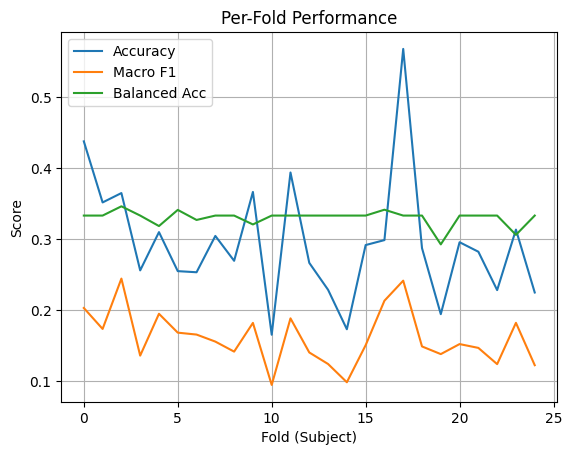


===== FINAL RESULTS =====
Model:             ModelType.CNN_Transformer
Seed:              42
Accuracy:          0.2953 ± 0.0851
Precision (macro): 0.1296 ± 0.0607
Recall (macro):    0.3305 ± 0.0108
F1 macro:          0.1612 ± 0.0380
Balanced Acc:      0.3305 ± 0.0108
Confusion matrix: [[ 552  455  898]
 [ 750  574 1032]
 [ 839  817  791]]


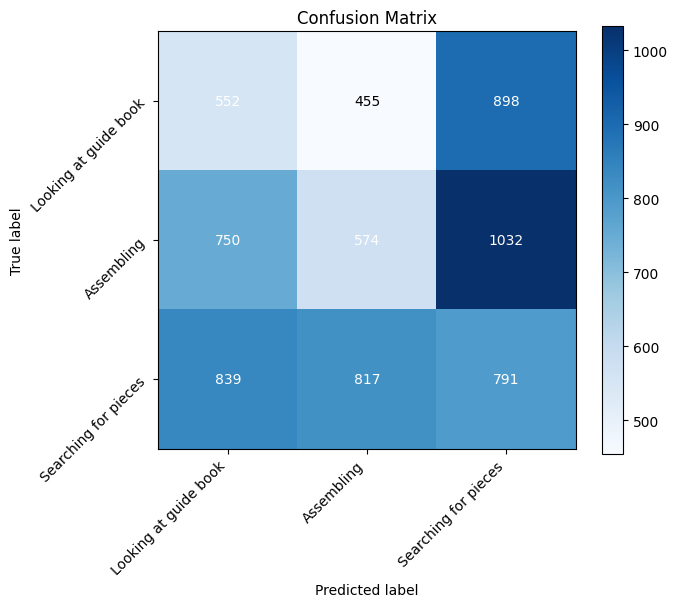

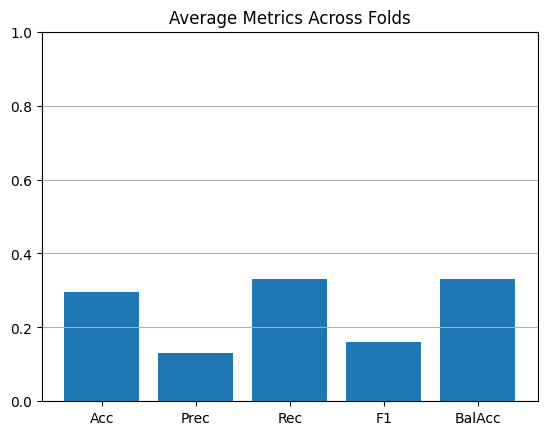

In [22]:
fold_metrics = evaluate_per_fold(per_fold_preds, per_fold_y)

final_results = evaluate_final(
    fold_metrics,
    per_fold_preds,
    per_fold_y
)

In [23]:
plot_pca_tsne(X_train_raw, y_test)

NameError: name 'X_train_raw' is not defined